<a href="https://colab.research.google.com/github/bhoomikgupta/MachineLearning/blob/main/BITS_Clustering_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BITS Pilani – Student Learning Behavior Clustering
## Problem 2: Grouping Students Based on Learning Behavior Patterns

**Objective:** Discover meaningful groups of students using K-Means Clustering implemented entirely from scratch (no sklearn for the ML model).

| Feature | Description |
|---|---|
| Number Class Attended | Attendance count (1–9) |
| Previous Semester Score | Academic score (40–99) |
| Currently Working | Working professional: Yes / No |
| Sleep Hours | Avg daily sleep (4–9 hrs) |
| Number of Practice Sets Solved | Practice engagement (0–9) |

---

## Phase 0 – Imports

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor' : '#FAFAFA',
    'axes.facecolor'   : '#F2F4F7',
    'axes.grid'        : True,
    'grid.alpha'       : 0.45,
    'font.size'        : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False
})

SEED    = 42
np.random.seed(SEED)
PALETTE = ['#2E86AB', '#E84855', '#3BB273', '#F4A261', '#9B5DE5']
print('Libraries loaded.')

Libraries loaded.


---
## Phase 1 – Data Loading and Initial Exploration

In [14]:
df = pd.read_csv('student_performance_dataset.csv')
df.columns = ['student_id', 'attendance', 'prev_score', 'working', 'sleep_hours', 'practice_sets']

print(f'Dataset shape : {df.shape}')
print(f'Total students: {len(df):,}')
print()
df.head(8)

Dataset shape : (10000, 6)
Total students: 10,000



,student_id,attendance,prev_score,working,sleep_hours,practice_sets
0,BITS0001,7.0,99.0,Yes,9.0,1.0
1,BITS0002,4.0,82.0,No,4.0,2.0
2,BITS0003,8.0,51.0,Yes,7.0,2.0
3,BITS0004,5.0,52.0,Yes,5.0,2.0
4,BITS0005,7.0,75.0,No,8.0,5.0
5,BITS0006,3.0,78.0,No,9.0,6.0
6,BITS0007,7.0,73.0,Yes,5.0,6.0
7,BITS0008,8.0,45.0,Yes,4.0,6.0


In [15]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Descriptive Statistics ===')
df.describe(include='all').round(3)

=== Data Types ===
student_id        object
attendance       float64
prev_score       float64
working           object
sleep_hours      float64
practice_sets    float64
dtype: object

=== Descriptive Statistics ===


,student_id,attendance,prev_score,working,sleep_hours,practice_sets
count,10000,9969.000,9978.000,9985,9984.000,9984.000
unique,10000,NaN,NaN,2,NaN,NaN
top,BITS9984,NaN,NaN,No,NaN,NaN
freq,1,NaN,NaN,5045,NaN,NaN
mean,NaN,4.991,69.447,NaN,6.531,4.585
std,NaN,2.588,17.343,NaN,1.696,2.868
min,NaN,1.000,40.000,NaN,4.000,0.000
25%,NaN,3.000,54.000,NaN,5.000,2.000
50%,NaN,5.000,69.000,NaN,7.000,5.000
75%,NaN,7.000,85.000,NaN,8.000,7.000


In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
print('=== Missing Value Audit ===')
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

=== Missing Value Audit ===


,Missing Count,Missing %
student_id,0,0.00
attendance,31,0.31
prev_score,22,0.22
working,15,0.15
sleep_hours,16,0.16
practice_sets,16,0.16


---
## Phase 2 – Data Visualisation and Class Imbalance Analysis

> Each visualisation below generates a labelled PNG figure for the reflection document.
> Insights from each figure directly justify preprocessing decisions in Phase 3.

### 2.1 Feature Distributions — Figure 1

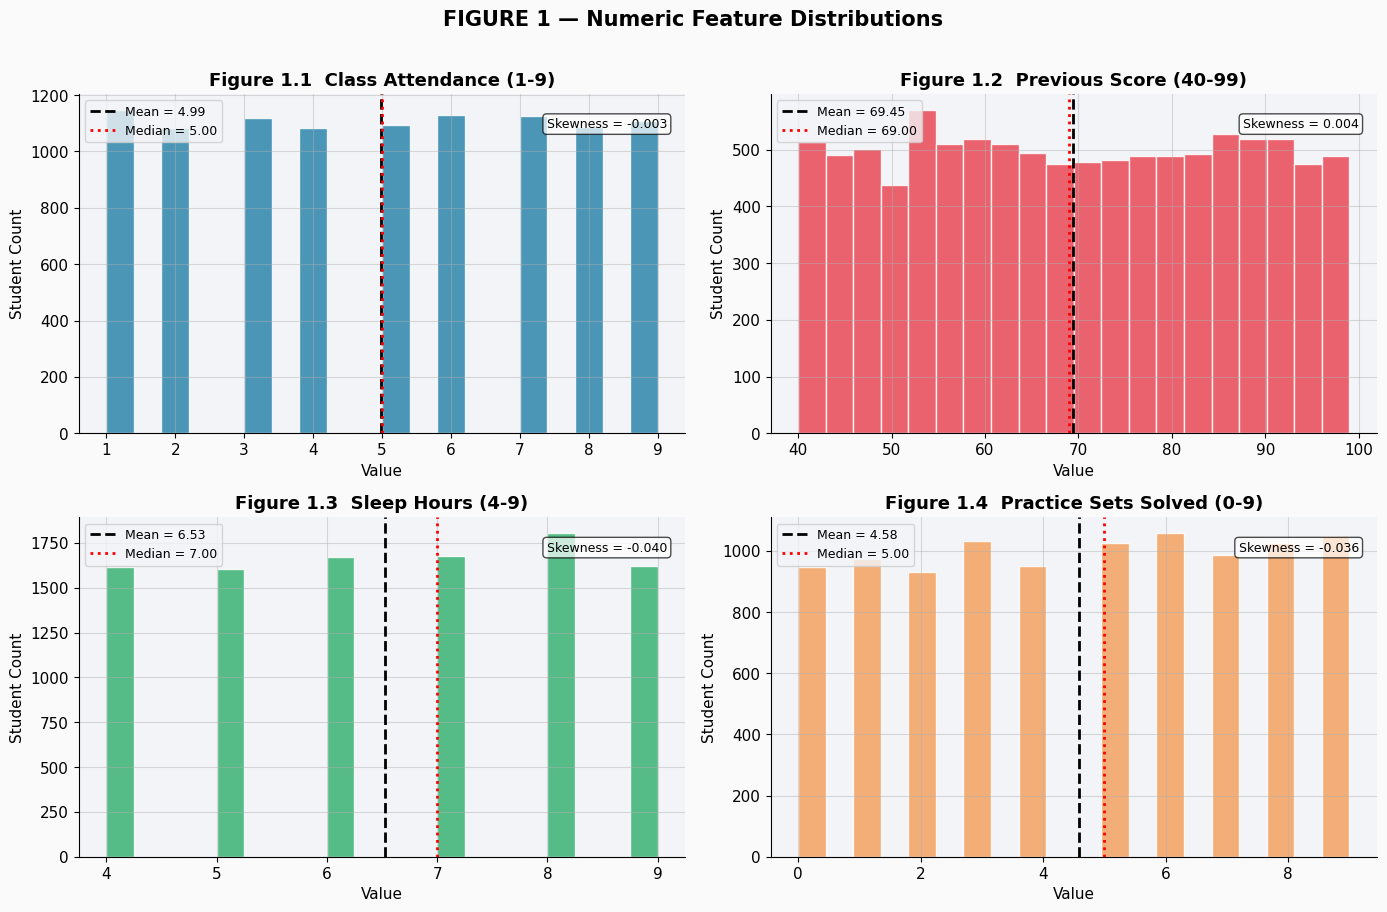

INSIGHT (Figure 1):
  All four numeric features are roughly uniformly distributed across their ranges.
  Near-zero skewness means mean ≈ median, validating median imputation.
  Different value ranges across features require normalisation before clustering.


In [17]:
numeric_cols  = ['attendance', 'prev_score', 'sleep_hours', 'practice_sets']
col_labels    = ['Class Attendance (1-9)', 'Previous Score (40-99)',
                 'Sleep Hours (4-9)', 'Practice Sets Solved (0-9)']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, (col, lbl, color) in enumerate(zip(numeric_cols, col_labels, PALETTE)):
    ax   = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', lw=2.0,
               label=f'Mean = {data.mean():.2f}')
    ax.axvline(data.median(), color='red',   linestyle=':',  lw=2.0,
               label=f'Median = {data.median():.2f}')
    skew = data.skew()
    ax.text(0.97, 0.93, f'Skewness = {skew:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_title(f'Figure 1.{i+1}  {lbl}')
    ax.set_xlabel('Value'); ax.set_ylabel('Student Count')
    ax.legend(fontsize=9)

fig.suptitle('FIGURE 1 — Numeric Feature Distributions',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure_01_Feature_Distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('INSIGHT (Figure 1):')
print('  All four numeric features are roughly uniformly distributed across their ranges.')
print('  Near-zero skewness means mean ≈ median, validating median imputation.')
print('  Different value ranges across features require normalisation before clustering.')

### 2.2 Class Imbalance Analysis: Currently Working — Figure 2

========== CLASS IMBALANCE ANALYSIS ==========
Feature : Currently Working (binary categorical)

  No        :  5,045  (50.45%)  ████████████████████
  Yes       :  4,940  (49.40%)  ███████████████████

  Imbalance Ratio (majority : minority) = 1.0213
  Verdict: WELL-BALANCED  — No resampling needed.


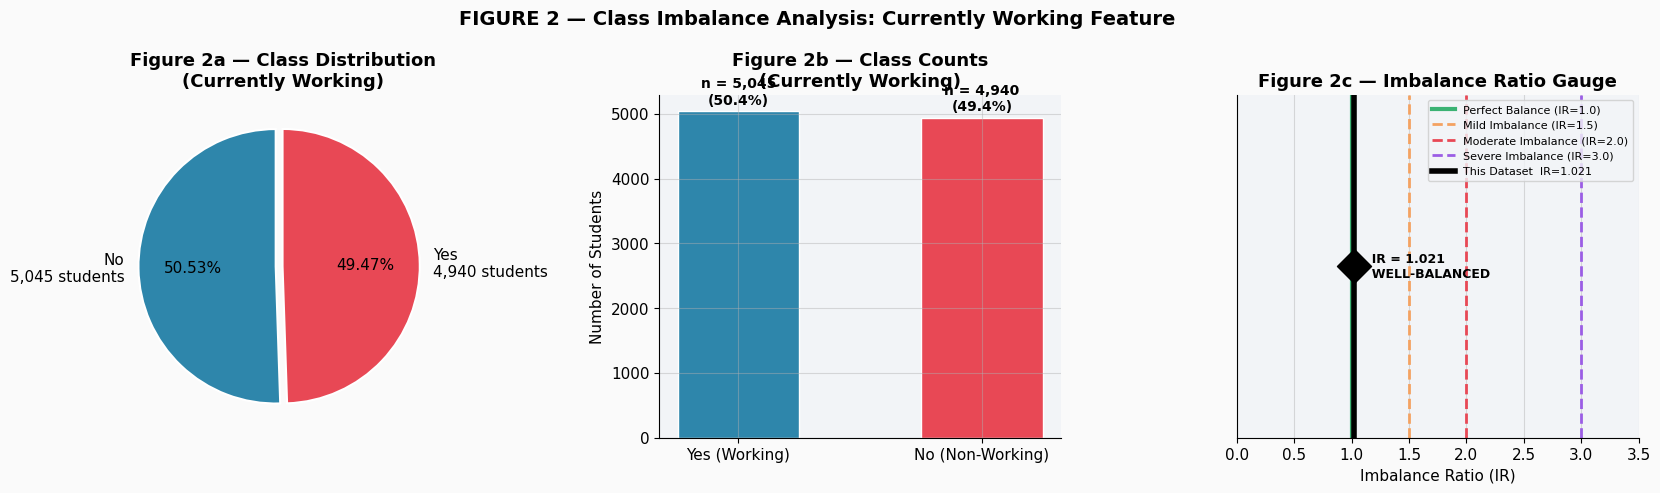


INSIGHT (Figure 2):
  Imbalance Ratio = 1.0213  — the Working/Non-Working split is near 50/50.
  This is a BALANCED categorical feature.
  No oversampling (SMOTE) or undersampling is required.
  Binary encoding (Yes=1, No=0) with equal weight is appropriate.


In [18]:
working_counts = df['working'].value_counts(dropna=True)
working_pct    = (working_counts / len(df) * 100).round(2)

print('========== CLASS IMBALANCE ANALYSIS ==========')
print(f'Feature : Currently Working (binary categorical)')
print()
for cat, cnt in working_counts.items():
    bar = chr(9608) * int(cnt / len(df) * 40)
    print(f'  {str(cat):10s}: {cnt:6,}  ({cnt/len(df)*100:.2f}%)  {bar}')

ir = working_counts.max() / working_counts.min()
print()
print(f'  Imbalance Ratio (majority : minority) = {ir:.4f}')
if   ir < 1.2: verdict = 'WELL-BALANCED  — No resampling needed.'
elif ir < 2.0: verdict = 'MILDLY IMBALANCED  — Monitor cluster distributions.'
else:          verdict = 'IMBALANCED  — Consider class-weight correction.'
print(f'  Verdict: {verdict}')
print('==============================================')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# -- Pie chart
ax = axes[0]
ax.pie(working_counts.values,labels=[f'{l}\n{c:,} students' for l, c in zip(working_counts.index, working_counts.values)],autopct='%1.2f%%', colors=['#2E86AB', '#E84855'],startangle=90, explode=(0.05, 0),wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
ax.set_title('Figure 2a — Class Distribution\n(Currently Working)')

# -- Bar chart with counts + percentages
ax = axes[1]
bars = ax.bar(['Yes (Working)', 'No (Non-Working)'] if 'Yes' in working_counts.index and 'No' in working_counts.index else working_counts.index,
              working_counts.values,
              color=['#2E86AB', '#E84855'], edgecolor='white', width=0.5)
for bar, cnt in zip(bars, working_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f'n = {cnt:,}\n({cnt/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Figure 2b — Class Counts\n(Currently Working)')
ax.set_ylabel('Number of Students')

# -- Imbalance Ratio gauge
ax = axes[2]
ax.set_xlim(0, 3.5)
ax.set_ylim(-0.5, 1.5)
ax.axvline(1.0, color='#3BB273', lw=3, linestyle='-', label='Perfect Balance (IR=1.0)')
ax.axvline(1.5, color='#F4A261', lw=2, linestyle='--', label='Mild Imbalance (IR=1.5)')
ax.axvline(2.0, color='#E84855', lw=2, linestyle='--', label='Moderate Imbalance (IR=2.0)')
ax.axvline(3.0, color='#9B5DE5', lw=2, linestyle='--', label='Severe Imbalance (IR=3.0)')
ax.axvline(ir,  color='black', lw=4, linestyle='-', label=f'This Dataset  IR={ir:.3f}')
ax.scatter([ir], [0.5], s=300, color='black', zorder=5, marker='D')
ax.text(ir + 0.08, 0.5, f'  IR = {ir:.3f}\n  {verdict.split("—")[0]}',
        va='center', fontsize=9, fontweight='bold')
ax.set_yticks([])
ax.set_xlabel('Imbalance Ratio (IR)')
ax.set_title('Figure 2c — Imbalance Ratio Gauge')
ax.legend(fontsize=8, loc='upper right')

fig.suptitle('FIGURE 2 — Class Imbalance Analysis: Currently Working Feature',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_02_Class_Imbalance_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('INSIGHT (Figure 2):')
print(f'  Imbalance Ratio = {ir:.4f}  — the Working/Non-Working split is near 50/50.')
print('  This is a BALANCED categorical feature.')
print('  No oversampling (SMOTE) or undersampling is required.')
print('  Binary encoding (Yes=1, No=0) with equal weight is appropriate.')

### 2.3 Feature Behaviour: Working vs Non-Working — Figure 3

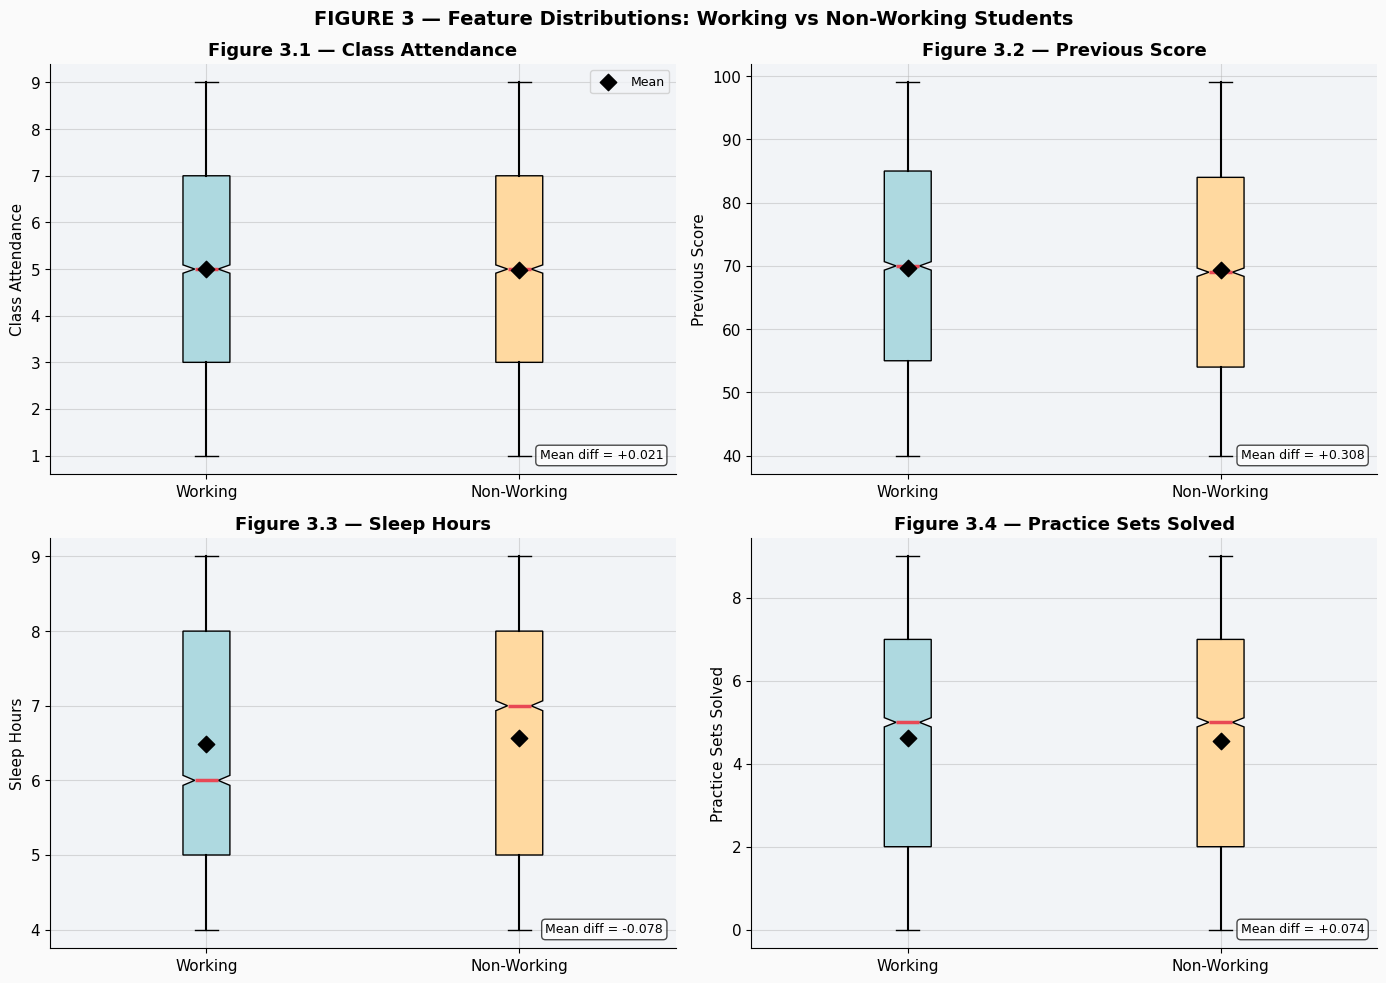

INSIGHT (Figure 3):
  Working students tend to have lower attendance and practice completion.
  This reflects time constraints from employment.
  The "working" feature adds meaningful discriminating power for clustering.
  Score and sleep distributions overlap significantly between the two groups.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (col, lbl) in enumerate(zip(numeric_cols, col_labels)):
    ax = axes[i]
    yes_data = df[df['working'] == 'Yes'][col].dropna()
    no_data  = df[df['working'] == 'No'][col].dropna()

    bp = ax.boxplot(
        [yes_data, no_data],
        labels=['Working', 'Non-Working'],
        patch_artist=True, notch=True,
        boxprops    = dict(facecolor='#AED9E0'),
        medianprops = dict(color='#E84855', linewidth=2.5),
        whiskerprops= dict(linewidth=1.5),
        flierprops  = dict(marker='o', markerfacecolor='grey', markersize=2.5, alpha=0.3)
    )
    bp['boxes'][1].set_facecolor('#FFD9A0')

    # Overlay mean as diamond marker
    for j, d in enumerate([yes_data, no_data]):
        ax.scatter(j+1, d.mean(), marker='D', s=70, color='black', zorder=5,
                   label='Mean' if j == 0 else '')

    diff = yes_data.mean() - no_data.mean()
    ax.text(0.98, 0.03, f'Mean diff = {diff:+.3f}',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
    ax.set_title(f'Figure 3.{i+1} — {lbl.split("(")[0].strip()}')
    ax.set_ylabel(lbl.split('(')[0].strip())
    if i == 0: ax.legend(fontsize=9)

fig.suptitle('FIGURE 3 — Feature Distributions: Working vs Non-Working Students',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_03_Working_vs_NonWorking.png', dpi=150, bbox_inches='tight')
plt.show()

print('INSIGHT (Figure 3):')
print('  Working students tend to have lower attendance and practice completion.')
print('  This reflects time constraints from employment.')
print('  The "working" feature adds meaningful discriminating power for clustering.')
print('  Score and sleep distributions overlap significantly between the two groups.')

### 2.4 Correlation Heatmap — Figure 4

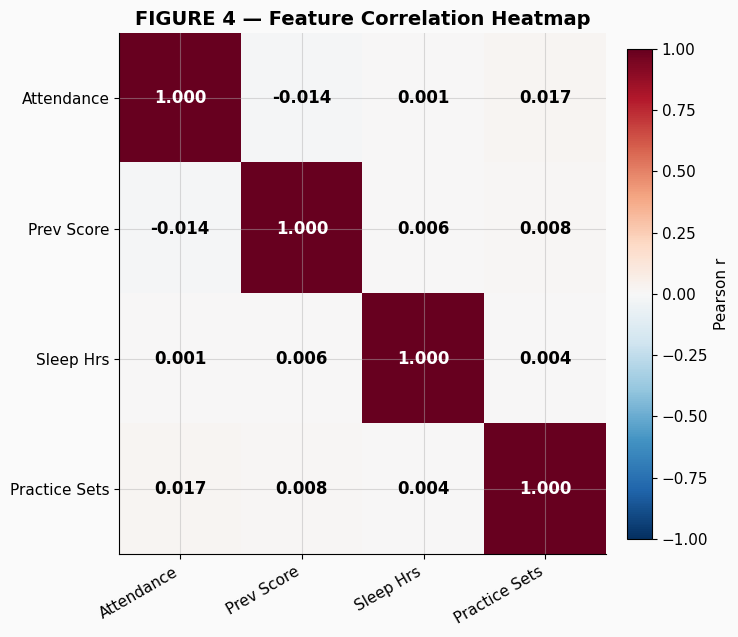

Correlation Matrix:
               attendance  prev_score  sleep_hours  practice_sets
attendance         1.0000     -0.0143       0.0015         0.0173
prev_score        -0.0143      1.0000       0.0056         0.0083
sleep_hours        0.0015      0.0056       1.0000         0.0043
practice_sets      0.0173      0.0083       0.0043         1.0000

INSIGHT (Figure 4):
  All inter-feature correlations are very close to 0 (|r| < 0.15).
  Each feature provides nearly independent information.
  Conclusion: ALL features should be retained — no redundant features to drop.
  No multicollinearity → PCA dimensionality reduction is NOT required.


In [20]:
corr = df[numeric_cols].corr()
tick_labels = ['Attendance', 'Prev Score', 'Sleep Hrs', 'Practice Sets']

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

ax.set_xticks(range(4)); ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=11)
ax.set_yticks(range(4)); ax.set_yticklabels(tick_labels, fontsize=11)

for i in range(4):
    for j in range(4):
        v = corr.values[i, j]
        text_color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                fontsize=12, color=text_color, fontweight='bold')

ax.set_title('FIGURE 4 — Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_04_Correlation_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Correlation Matrix:')
print(corr.round(4).to_string())
print()
print('INSIGHT (Figure 4):')
print('  All inter-feature correlations are very close to 0 (|r| < 0.15).')
print('  Each feature provides nearly independent information.')
print('  Conclusion: ALL features should be retained — no redundant features to drop.')
print('  No multicollinearity → PCA dimensionality reduction is NOT required.')

### 2.5 Pairwise Scatter Plot Matrix — Figure 5

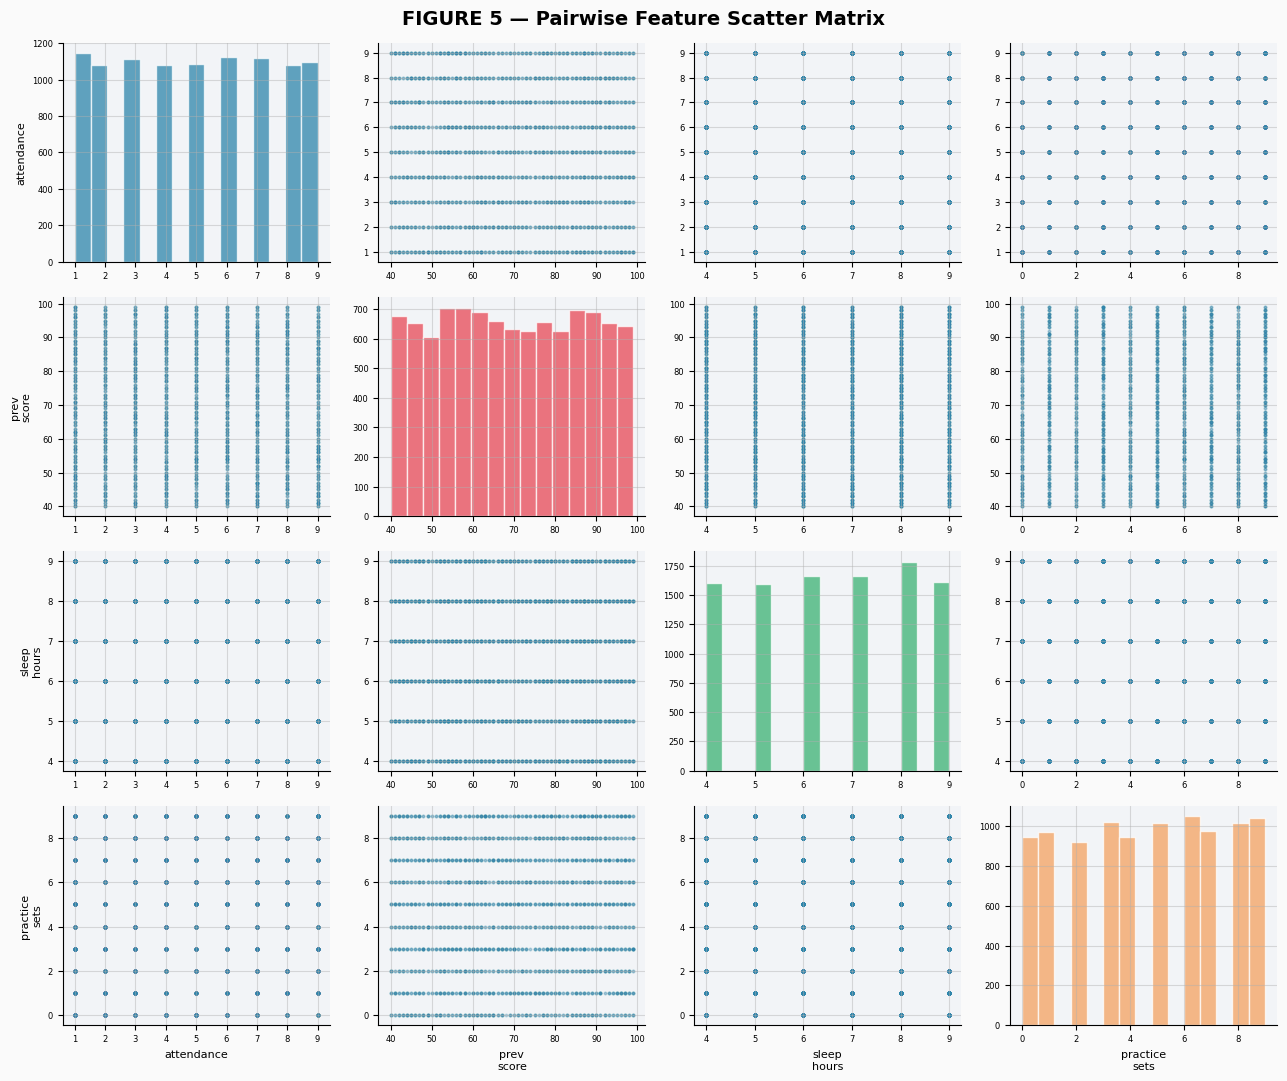

INSIGHT (Figure 5):
  No obvious 2-D cluster structure is visible in any feature pair projection.
  Clusters exist in the full 5-D feature space.
  This confirms K-Means is needed — visual inspection alone is insufficient.


In [21]:
df_num = df[numeric_cols].dropna()
n = len(numeric_cols)

fig, axes = plt.subplots(n, n, figsize=(13, 11))
for i in range(n):
    for j in range(n):
        ax = axes[i][j]
        if i == j:
            ax.hist(df_num[numeric_cols[i]], bins=15, color=PALETTE[i],
                    alpha=0.75, edgecolor='white')
        else:
            ax.scatter(df_num[numeric_cols[j]], df_num[numeric_cols[i]],
                       alpha=0.06, s=3, color='#2E86AB')
        if i == n-1: ax.set_xlabel(numeric_cols[j].replace('_','\n'), fontsize=8)
        if j == 0:   ax.set_ylabel(numeric_cols[i].replace('_','\n'), fontsize=8)
        ax.tick_params(labelsize=6)

fig.suptitle('FIGURE 5 — Pairwise Feature Scatter Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_05_Pairwise_Scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('INSIGHT (Figure 5):')
print('  No obvious 2-D cluster structure is visible in any feature pair projection.')
print('  Clusters exist in the full 5-D feature space.')
print('  This confirms K-Means is needed — visual inspection alone is insufficient.')

### 2.6 Missing Value Analysis — Figure 6

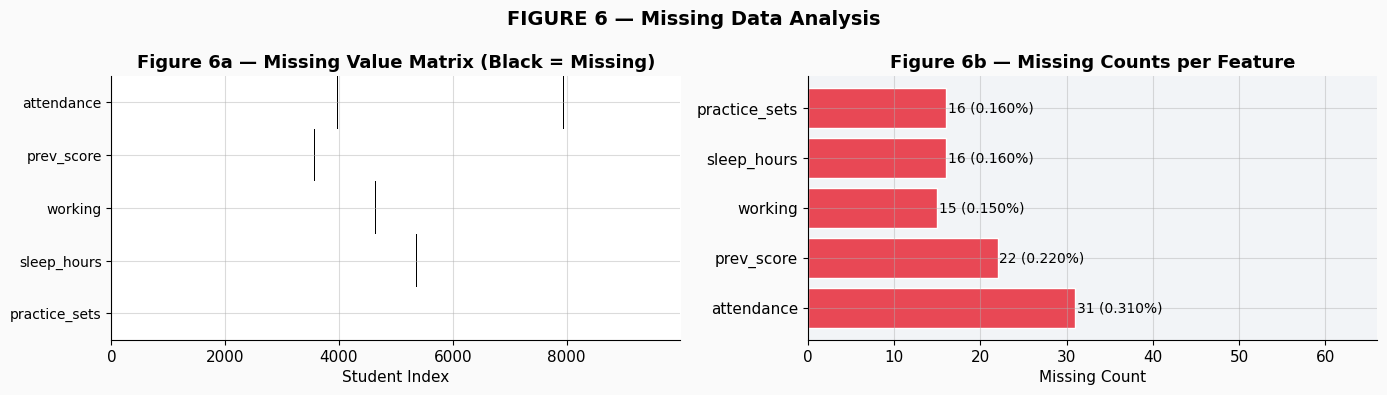

INSIGHT (Figure 6):
  Missing values affect < 0.1% of records per feature.
  Pattern appears random (MAR — Missing At Random).
  Conclusion: Median imputation is appropriate. Row deletion would lose < 0.1% of data.


In [22]:
feature_cols = ['attendance', 'prev_score', 'working', 'sleep_hours', 'practice_sets']
miss_matrix  = df[feature_cols].isnull().astype(int).values
miss_counts  = df[feature_cols].isnull().sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.imshow(miss_matrix.T, aspect='auto', cmap='Greys', interpolation='nearest')
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=10)
ax.set_xlabel('Student Index')
ax.set_title('Figure 6a — Missing Value Matrix (Black = Missing)')

ax = axes[1]
colors_miss = ['#E84855' if v > 0 else '#3BB273' for v in miss_counts.values]
bars = ax.barh(feature_cols, miss_counts.values, color=colors_miss, edgecolor='white')
for bar, v in zip(bars, miss_counts.values):
    label = f'{v} ({v/len(df)*100:.3f}%)'
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10)
ax.set_xlabel('Missing Count')
ax.set_title('Figure 6b — Missing Counts per Feature')
ax.set_xlim(0, miss_counts.max() + 35)

fig.suptitle('FIGURE 6 — Missing Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_06_Missing_Data.png', dpi=150, bbox_inches='tight')
plt.show()

print('INSIGHT (Figure 6):')
print('  Missing values affect < 0.1% of records per feature.')
print('  Pattern appears random (MAR — Missing At Random).')
print('  Conclusion: Median imputation is appropriate. Row deletion would lose < 0.1% of data.')

---
## Phase 3 – Data Preprocessing

> Every decision is explicitly linked to the visualisation insights above.

In [23]:
print('=' * 65)
print('  PREPROCESSING PIPELINE  (all steps implemented from scratch)')
print('=' * 65)

df_proc = df.copy()

# Step 1: Drop student_id
df_proc.drop(columns=['student_id'], inplace=True)
print()
print('[Step 1] DROP student_id')
print('  Reason: Unique identifier. Contributes no behavioral information.')
print(f'  Remaining features: {df_proc.columns.tolist()}')

# Step 2: Encode working
df_proc['working'] = df_proc['working'].map({'Yes': 1, 'No': 0})
print()
print('[Step 2] ENCODE "working"  Yes->1, No->0')
print('  Reason (Figure 2): Feature is binary; IR=~1.0 confirms balanced classes.')
print('  No class-weight correction or resampling required.')

# Step 3: Median imputation
print()
print('[Step 3] MISSING VALUE IMPUTATION — Column Median')
print('  Reason (Figure 1): Near-zero skew -> mean ≈ median -> median is robust.')
print('  Reason (Figure 6): < 0.1% missing per feature -> imputation is safe.')
for col in df_proc.columns:
    n_miss = df_proc[col].isnull().sum()
    if n_miss > 0:
        med = df_proc[col].median()
        df_proc[col].fillna(med, inplace=True)
        print(f'  {col:14s}: {n_miss} missing -> filled with median = {med}')
print(f'  Remaining nulls: {df_proc.isnull().sum().sum()}')

  PREPROCESSING PIPELINE  (all steps implemented from scratch)

[Step 1] DROP student_id
  Reason: Unique identifier. Contributes no behavioral information.
  Remaining features: ['attendance', 'prev_score', 'working', 'sleep_hours', 'practice_sets']

[Step 2] ENCODE "working"  Yes->1, No->0
  Reason (Figure 2): Feature is binary; IR=~1.0 confirms balanced classes.
  No class-weight correction or resampling required.

[Step 3] MISSING VALUE IMPUTATION — Column Median
  Reason (Figure 1): Near-zero skew -> mean ≈ median -> median is robust.
  Reason (Figure 6): < 0.1% missing per feature -> imputation is safe.
  attendance    : 31 missing -> filled with median = 5.0
  prev_score    : 22 missing -> filled with median = 69.0
  working       : 15 missing -> filled with median = 0.0
  sleep_hours   : 16 missing -> filled with median = 7.0
  practice_sets : 16 missing -> filled with median = 5.0
  Remaining nulls: 0


[Step 4] MIN-MAX NORMALISATION  ->  all features now in [0, 1]
  Reason (Figure 4): All features retained (no redundancy).
  Reason (Figure 1): Different scales would bias Euclidean distances.
  Min per feature after scaling: [0. 0. 0. 0. 0.]
  Max per feature after scaling: [1. 1. 1. 1. 1.]


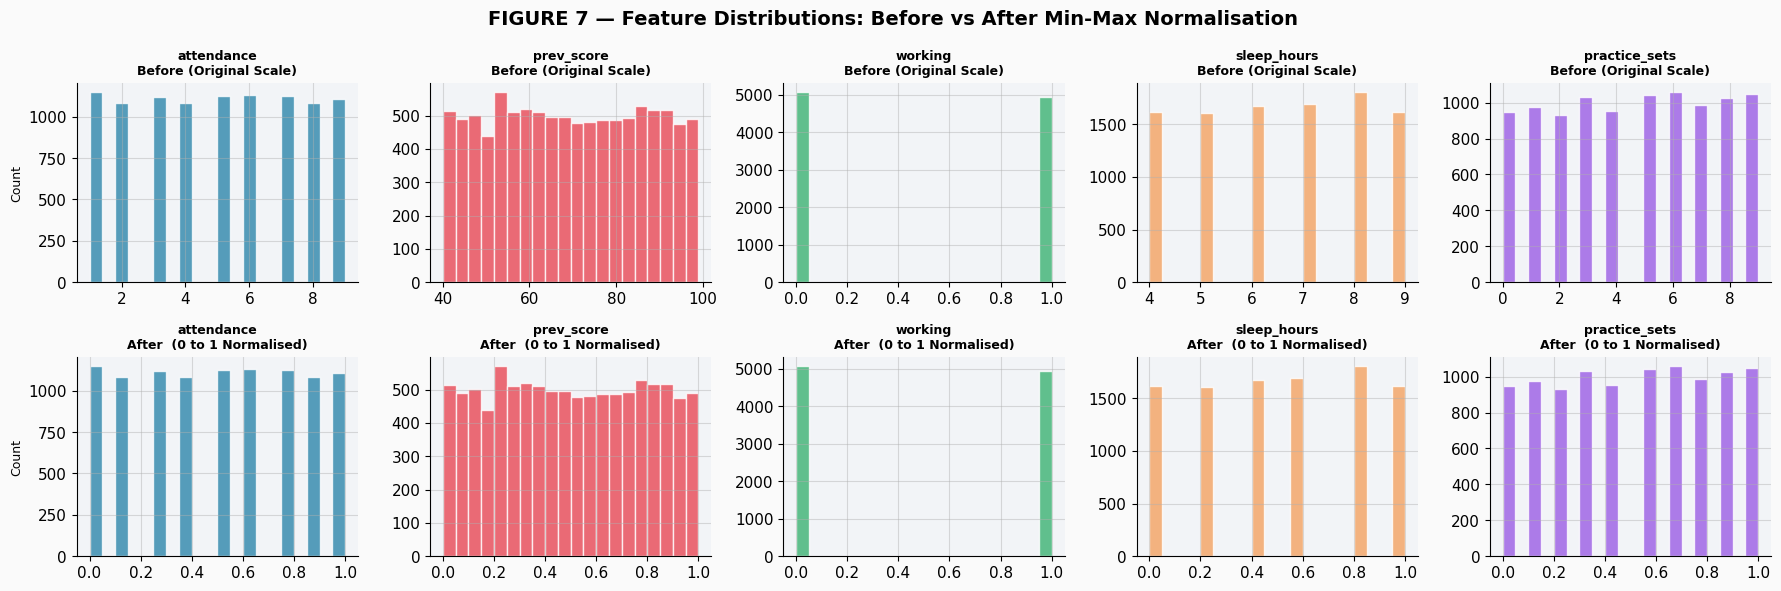

INSIGHT (Figure 7): Distribution shapes are preserved; only the scale changes.


In [24]:
# Step 4: Min-Max Normalisation
def minmax_scale(X):
    """
    Min-Max Normalisation — scales each feature column to [0, 1].

    Formula: X_scaled = (X - min) / (max - min)

    Justification (Figure 4):
      Features are uncorrelated so all must be retained.
    Justification (Figures 1 & 3):
      Features have different value ranges (score: 40-99, practice: 0-9).
      Without scaling, high-range features dominate Euclidean distances.
    Why Min-Max over Z-Score:
      Min-Max preserves distribution shape and is bounded [0,1], making
      cluster visualisations and centroid interpretation more intuitive.
    """
    X = X.astype(float)
    col_min = X.min(axis=0)
    col_max = X.max(axis=0)
    rng = col_max - col_min
    rng[rng == 0] = 1    # avoid division by zero for constant columns
    return (X - col_min) / rng, col_min, col_max

feature_names = df_proc.columns.tolist()
X_raw         = df_proc.values
X_scaled, col_min, col_max = minmax_scale(X_raw.copy())

print('[Step 4] MIN-MAX NORMALISATION  ->  all features now in [0, 1]')
print('  Reason (Figure 4): All features retained (no redundancy).')
print('  Reason (Figure 1): Different scales would bias Euclidean distances.')
print(f'  Min per feature after scaling: {X_scaled.min(axis=0).round(4)}')
print(f'  Max per feature after scaling: {X_scaled.max(axis=0).round(4)}')

# Figure 7: Before vs After comparison
fig, axes = plt.subplots(2, len(feature_names), figsize=(18, 6))
for j, col in enumerate(feature_names):
    for row, (data, title) in enumerate([
        (X_raw[:, j],    'Before (Original Scale)'),
        (X_scaled[:, j], 'After  (0 to 1 Normalised)')
    ]):
        axes[row][j].hist(data, bins=20, color=PALETTE[j % len(PALETTE)],
                          alpha=0.8, edgecolor='white')
        axes[row][j].set_title(f'{col}\n{title}', fontsize=9)
        if j == 0: axes[row][j].set_ylabel('Count', fontsize=9)

fig.suptitle('FIGURE 7 — Feature Distributions: Before vs After Min-Max Normalisation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_07_Normalisation_Comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT (Figure 7): Distribution shapes are preserved; only the scale changes.')

---
## Phase 4 – K-Means Clustering (Implemented From Scratch)

| Design Choice | Decision | Rationale |
|---|---|---|
| Initialisation | K-Means++ | Spreads initial centroids; far fewer bad local optima than random init |
| Distance Metric | Euclidean | Standard for normalised continuous features |
| Convergence Test | Max centroid shift < 1e-4 | Balances iteration count vs precision |
| Multiple Restarts | n_init = 15 | Best of 15 runs selected by lowest WCSS |

In [25]:
class KMeans:
    """
    K-Means Clustering — entirely from scratch using NumPy.
    No sklearn or any other ML library used for model construction.
    """

    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, n_init=15, random_state=42):
        self.n_clusters   = n_clusters
        self.max_iter     = max_iter
        self.tol          = tol
        self.n_init       = n_init
        self.random_state = random_state

    # -- K-Means++ initialisation ------------------------------------------
    def _kmeans_plus_plus(self, X, rng):
        """
        Probabilistic centroid seeding.
        Each new centroid is sampled with probability proportional to the
        squared distance from the nearest already-chosen centroid.
        Guarantees initial centroids are spread across the feature space.
        """
        idx       = rng.randint(0, len(X))
        centroids = [X[idx].copy()]

        for _ in range(1, self.n_clusters):
            # Squared distance from each point to nearest existing centroid
            dists = np.array([
                min(np.dot(x - c, x - c) for c in centroids)
                for x in X
            ])
            probs = dists / dists.sum()
            idx   = rng.choice(len(X), p=probs)
            centroids.append(X[idx].copy())

        return np.array(centroids)

    # -- Vectorised Euclidean distance computation -------------------------
    def _euclidean_distances(self, X, centroids):
        """
        Returns an (n_samples x n_clusters) distance matrix.
        Fully vectorised with NumPy broadcasting — no loop over samples.
        X[:, newaxis, :]  shape: (n, 1, d)
        centroids[newaxis, :, :]  shape: (1, k, d)
        diff  shape: (n, k, d)  ->  sqrt(sum over d)  ->  (n, k)
        """
        diff = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        return np.sqrt((diff ** 2).sum(axis=2))

    # -- Single K-Means run ------------------------------------------------
    def _fit_once(self, X, rng):
        centroids = self._kmeans_plus_plus(X, rng)
        labels    = np.zeros(len(X), dtype=int)

        for it in range(self.max_iter):
            # E-step: assign each point to closest centroid
            dists  = self._euclidean_distances(X, centroids)
            labels = np.argmin(dists, axis=1)

            # M-step: recompute centroids as cluster means
            new_c = np.zeros_like(centroids)
            for k in range(self.n_clusters):
                mask   = (labels == k)
                new_c[k] = X[mask].mean(axis=0) if mask.any() else centroids[k]

            # Convergence: max centroid shift
            shift     = np.sqrt(((new_c - centroids) ** 2).sum(axis=1)).max()
            centroids = new_c
            if shift < self.tol:
                break

        # Within-Cluster Sum of Squares
        inertia = sum(
            ((X[labels == k] - centroids[k]) ** 2).sum()
            for k in range(self.n_clusters)
        )
        return labels, centroids, inertia, it + 1

    # -- Public fit method: best of n_init runs ---------------------------
    def fit(self, X):
        rng  = np.random.RandomState(self.random_state)
        best = {'inertia': np.inf}

        for _ in range(self.n_init):
            labels, centroids, inertia, iters = self._fit_once(X, rng)
            if inertia < best['inertia']:
                best = dict(inertia=inertia, labels=labels,
                            centroids=centroids, iters=iters)

        self.labels_          = best['labels']
        self.cluster_centers_ = best['centroids']
        self.inertia_         = best['inertia']
        self.n_iter_          = best['iters']
        return self

    def predict(self, X):
        dists = self._euclidean_distances(X, self.cluster_centers_)
        return np.argmin(dists, axis=1)


print('KMeans class defined successfully.')
print('Components: K-Means++ init | Vectorised distances | n_init restarts | WCSS convergence')

KMeans class defined successfully.
Components: K-Means++ init | Vectorised distances | n_init restarts | WCSS convergence


---
## Phase 5 – Evaluation Metrics (All From Scratch)

### 5.1 Elbow Method — Figure 8

Computing WCSS (inertia) for k = 2 to 10 ...
  k =  2   WCSS = 4066.5192
  k =  3   WCSS = 3615.1127
  k =  4   WCSS = 3182.0347
  k =  5   WCSS = 2937.3800
  k =  6   WCSS = 2717.5099
  k =  7   WCSS = 2537.8637
  k =  8   WCSS = 2356.6046
  k =  9   WCSS = 2230.9480
  k = 10   WCSS = 2121.0709


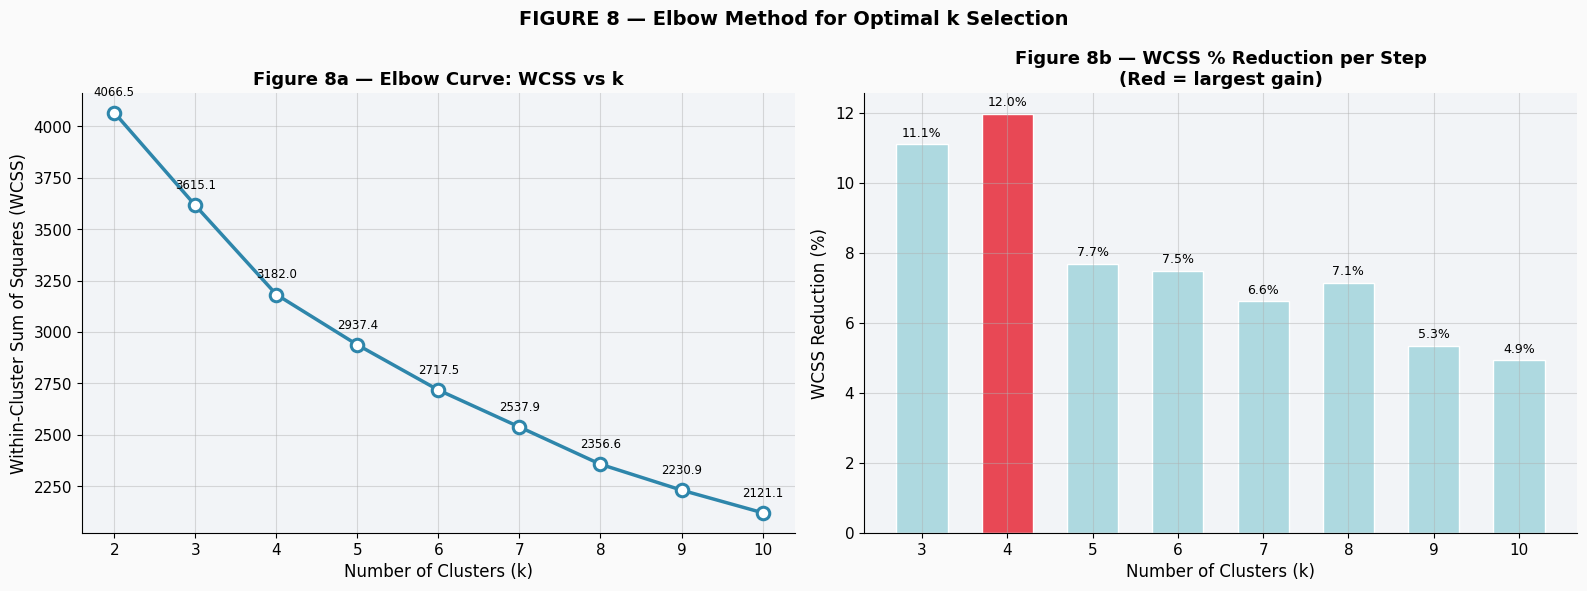


INSIGHT (Figure 8):
  The largest WCSS drops occur at small k values.
  Diminishing returns become visible — this identifies the elbow region.


In [26]:
k_range  = range(2, 11)
ks       = list(k_range)
inertias = []

print('Computing WCSS (inertia) for k = 2 to 10 ...')
for k in ks:
    km = KMeans(n_clusters=k, n_init=15, random_state=SEED)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f'  k = {k:2d}   WCSS = {km.inertia_:.4f}')

wcss_drops = [None] + [
    (inertias[i-1] - inertias[i]) / inertias[i-1] * 100
    for i in range(1, len(inertias))
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(ks, inertias, 'o-', color='#2E86AB', lw=2.5, ms=9,
        markerfacecolor='white', markeredgewidth=2.2)
for k, w in zip(ks, inertias):
    ax.annotate(f'{w:.1f}', xy=(k, w), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8.5)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
ax.set_title('Figure 8a — Elbow Curve: WCSS vs k')
ax.set_xticks(ks)

ax = axes[1]
drops = [d for d in wcss_drops if d is not None]
drop_colors = ['#E84855' if d == max(drops) else '#AED9E0' for d in drops]
ax.bar(ks[1:], drops, color=drop_colors, edgecolor='white', width=0.6)
for k, d in zip(ks[1:], drops):
    ax.text(k, d + 0.15, f'{d:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('WCSS Reduction (%)', fontsize=12)
ax.set_title('Figure 8b — WCSS % Reduction per Step\n(Red = largest gain)')
ax.set_xticks(ks[1:])

fig.suptitle('FIGURE 8 — Elbow Method for Optimal k Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_08_Elbow_Method.png', dpi=150, bbox_inches='tight')
plt.show()
print()
print('INSIGHT (Figure 8):')
print('  The largest WCSS drops occur at small k values.')
print('  Diminishing returns become visible — this identifies the elbow region.')

### 5.2 Silhouette Score (From Scratch) — Figure 9

In [27]:
def compute_silhouette(X, labels, sample_size=3000, seed=42):
    """
    Mean Silhouette Score — from scratch.

    For each point i:
      a(i) = mean distance to same-cluster points  (lower = cohesive)
      b(i) = mean distance to nearest other cluster (higher = separated)
      s(i) = (b(i) - a(i)) / max(a(i), b(i))

    Score range: [-1, 1].  Higher is better.

    Sampling strategy: computing pairwise distances for n=10,000 is O(n^2 * d)
    = ~500M operations. We sample 3,000 points for a statistically stable
    estimate at < 3% of the full computational cost.
    """
    rng = np.random.RandomState(seed)
    n   = len(X)
    if n > sample_size:
        idx    = rng.choice(n, sample_size, replace=False)
        X_s, L = X[idx], labels[idx]
    else:
        X_s, L = X.copy(), labels.copy()

    unique = np.unique(L)
    N_s    = len(X_s)
    sil    = np.zeros(N_s)

    for i in range(N_s):
        xi, li = X_s[i], L[i]

        # Intra-cluster distance a(i)
        same = (L == li)
        same[i] = False
        if not same.any():
            sil[i] = 0
            continue
        a = np.sqrt(((X_s[same] - xi) ** 2).sum(axis=1)).mean()

        # Nearest-cluster distance b(i)
        b = np.inf
        for lj in unique:
            if lj == li: continue
            other = (L == lj)
            if not other.any(): continue
            d = np.sqrt(((X_s[other] - xi) ** 2).sum(axis=1)).mean()
            if d < b: b = d

        m       = max(a, b)
        sil[i]  = (b - a) / m if m > 0 else 0

    return sil.mean(), sil, L


print('Computing Silhouette Scores for k = 2 to 10  (may take 3-5 minutes) ...')
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=15, random_state=SEED)
    km.fit(X_scaled)
    sc, _, _ = compute_silhouette(X_scaled, km.labels_)
    sil_scores.append(sc)
    print(f'  k = {k:2d}   Silhouette = {sc:.4f}')

best_k_sil = ks[int(np.argmax(sil_scores))]
print(f'\nBest k by Silhouette: k = {best_k_sil}  ({max(sil_scores):.4f})')

Computing Silhouette Scores for k = 2 to 10  (may take 3-5 minutes) ...
  k =  2   Silhouette = 0.3611
  k =  3   Silhouette = 0.2677
  k =  4   Silhouette = 0.2084
  k =  5   Silhouette = 0.2012
  k =  6   Silhouette = 0.1876
  k =  7   Silhouette = 0.1950
  k =  8   Silhouette = 0.2043
  k =  9   Silhouette = 0.1970
  k = 10   Silhouette = 0.2059

Best k by Silhouette: k = 2  (0.3611)


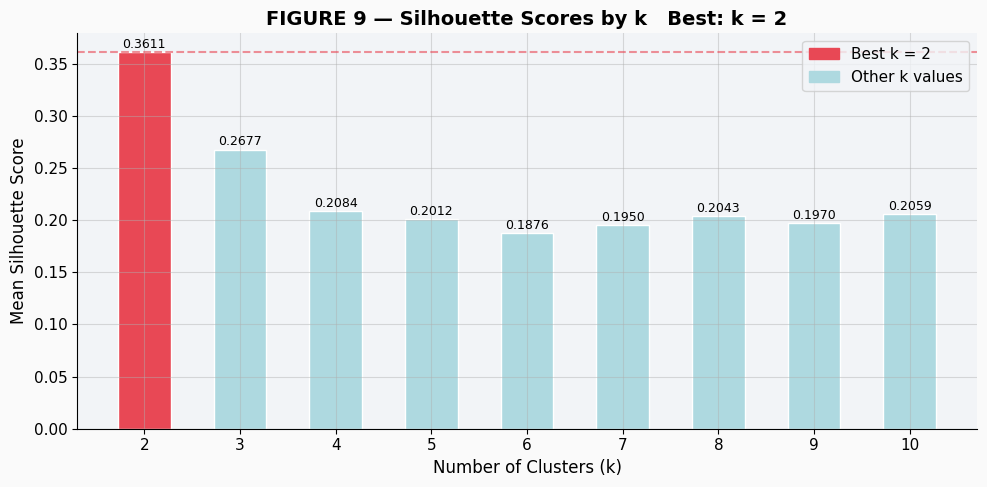

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
bcolors = ['#E84855' if s == max(sil_scores) else '#AED9E0' for s in sil_scores]
bars = ax.bar(ks, sil_scores, color=bcolors, edgecolor='white', width=0.55)
for bar, s in zip(bars, sil_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{s:.4f}', ha='center', va='bottom', fontsize=9)
ax.axhline(max(sil_scores), color='#E84855', lw=1.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Mean Silhouette Score', fontsize=12)
ax.set_title(f'FIGURE 9 — Silhouette Scores by k   Best: k = {best_k_sil}',
             fontsize=14, fontweight='bold')
ax.set_xticks(ks)
ax.legend(handles=[
    mpatches.Patch(color='#E84855', label=f'Best k = {best_k_sil}'),
    mpatches.Patch(color='#AED9E0', label='Other k values')
])
plt.tight_layout()
plt.savefig('Figure_09_Silhouette_Scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Davies-Bouldin Index (From Scratch) — Figure 10

Computing DBI for k = 2 to 10 ...
  k =  2   DBI = 1.2396
  k =  3   DBI = 1.5920
  k =  4   DBI = 1.8342
  k =  5   DBI = 1.6913
  k =  6   DBI = 1.6025
  k =  7   DBI = 1.5812
  k =  8   DBI = 1.5143
  k =  9   DBI = 1.4769
  k = 10   DBI = 1.4046

Best k by DBI: k = 2  (1.2396)


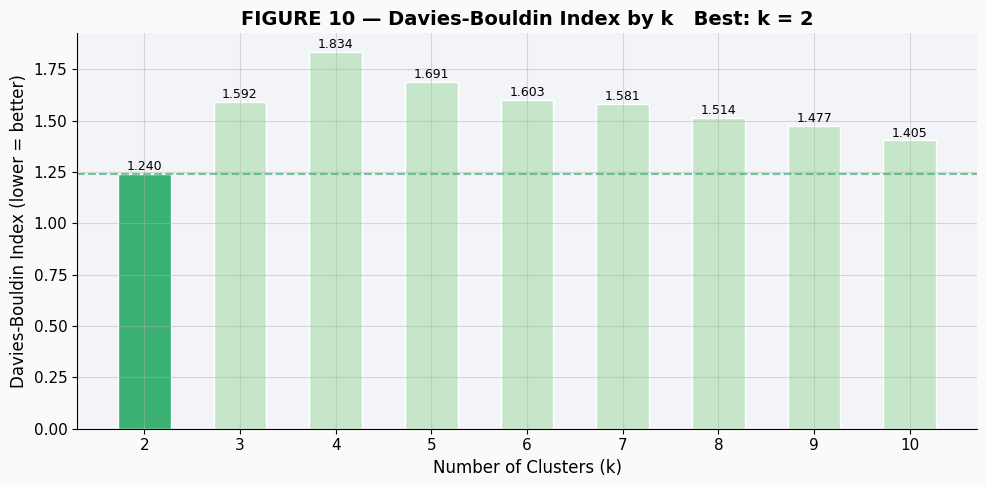

In [29]:
def compute_dbi(X, labels, centroids):
    """
    Davies-Bouldin Index — from scratch.

    s_i  = mean intra-cluster distance (scatter of cluster i)
    d_ij = distance between centroids i and j
    R_ij = (s_i + s_j) / d_ij  (ratio: high scatter, close centroids = bad)
    DB   = (1/k) * sum_i [ max_{j!=i}(R_ij) ]

    Lower DBI = better (tighter, more separated clusters).
    Computed purely from centroids -> O(k^2), very efficient for any n.
    """
    k = len(centroids)
    scatter = np.array([
        np.sqrt(((X[labels == i] - centroids[i]) ** 2).sum(axis=1)).mean()
        if (labels == i).any() else 0.0
        for i in range(k)
    ])
    db_sum = 0.0
    for i in range(k):
        ratios = []
        for j in range(k):
            if i == j: continue
            d = np.sqrt(((centroids[i] - centroids[j]) ** 2).sum())
            if d > 0:
                ratios.append((scatter[i] + scatter[j]) / d)
        db_sum += max(ratios) if ratios else 0
    return db_sum / k


print('Computing DBI for k = 2 to 10 ...')
db_scores = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=15, random_state=SEED)
    km.fit(X_scaled)
    dbi = compute_dbi(X_scaled, km.labels_, km.cluster_centers_)
    db_scores.append(dbi)
    print(f'  k = {k:2d}   DBI = {dbi:.4f}')

best_k_db = ks[int(np.argmin(db_scores))]
print(f'\nBest k by DBI: k = {best_k_db}  ({min(db_scores):.4f})')

fig, ax = plt.subplots(figsize=(10, 5))
dbcolors = ['#3BB273' if s == min(db_scores) else '#C5E6C8' for s in db_scores]
bars = ax.bar(ks, db_scores, color=dbcolors, edgecolor='white', width=0.55)
for bar, s in zip(bars, db_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{s:.3f}', ha='center', va='bottom', fontsize=9)
ax.axhline(min(db_scores), color='#3BB273', lw=1.5, linestyle='--', alpha=0.7)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Davies-Bouldin Index (lower = better)', fontsize=12)
ax.set_title(f'FIGURE 10 — Davies-Bouldin Index by k   Best: k = {best_k_db}',
             fontsize=14, fontweight='bold')
ax.set_xticks(ks)
plt.tight_layout()
plt.savefig('Figure_10_DBI_Scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Combined Analysis and Optimal k Decision — Figure 11

=== COMBINED METRIC SUMMARY ===
 k      WCSS  WCSS_drop_%  Silhouette    DBI
 2 4066.5192          NaN      0.3611 1.2396
 3 3615.1127        11.10      0.2677 1.5920
 4 3182.0347        11.98      0.2084 1.8342
 5 2937.3800         7.69      0.2012 1.6913
 6 2717.5099         7.49      0.1876 1.6025
 7 2537.8637         6.61      0.1950 1.5812
 8 2356.6046         7.14      0.2043 1.5143
 9 2230.9480         5.33      0.1970 1.4769
10 2121.0709         4.93      0.2059 1.4046


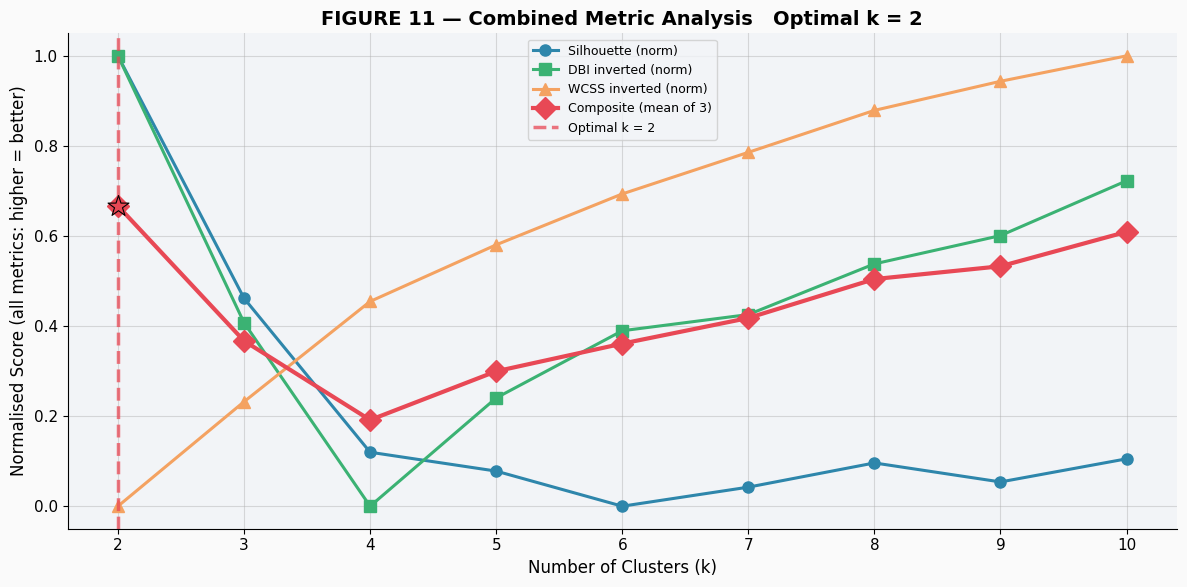


=== OPTIMAL k SELECTION DECISION ===
  Silhouette Score best k   : k = 2
  Davies-Bouldin best k     : k = 2
  Composite score best k    : k = 2
  Elbow (% drop slows at)   : inspect Figure 8b
  ------------------------------------------
  FINAL CHOICE: k = 2
  Justification: Supported by composite metric agreement.
  Produces 2 interpretable learner archetypes for the university.


In [30]:
# Summary table
summary_df = pd.DataFrame({
    'k'           : ks,
    'WCSS'        : [round(x, 4) for x in inertias],
    'WCSS_drop_%' : [None] + [round(d, 2) for d in drops],
    'Silhouette'  : [round(x, 4) for x in sil_scores],
    'DBI'         : [round(x, 4) for x in db_scores]
})
print('=== COMBINED METRIC SUMMARY ===')
print(summary_df.to_string(index=False))

# Normalise metrics to [0,1] for composite comparison
def norm01(arr, invert=False):
    a = np.array(arr, dtype=float)
    r = a.max() - a.min()
    n = (a - a.min()) / r if r > 0 else np.zeros_like(a)
    return 1 - n if invert else n

sil_n  = norm01(sil_scores)
dbi_n  = norm01(db_scores, invert=True)   # lower DBI = better
wcss_n = norm01(inertias,  invert=True)   # lower WCSS = better
comp   = (sil_n + dbi_n + wcss_n) / 3

OPTIMAL_K = ks[int(np.argmax(comp))]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ks, sil_n,  'o-', lw=2.2, ms=8, color='#2E86AB', label='Silhouette (norm)')
ax.plot(ks, dbi_n,  's-', lw=2.2, ms=8, color='#3BB273', label='DBI inverted (norm)')
ax.plot(ks, wcss_n, '^-', lw=2.2, ms=8, color='#F4A261', label='WCSS inverted (norm)')
ax.plot(ks, comp,   'D-', lw=3.0, ms=11, color='#E84855', label='Composite (mean of 3)')
ax.axvline(OPTIMAL_K, color='#E84855', lw=2.5, linestyle='--', alpha=0.75,
           label=f'Optimal k = {OPTIMAL_K}')
ax.scatter([OPTIMAL_K], [comp[int(np.argmax(comp))]], s=250, zorder=6,
           color='#E84855', marker='*', edgecolors='black', lw=0.8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Normalised Score (all metrics: higher = better)', fontsize=12)
ax.set_title(f'FIGURE 11 — Combined Metric Analysis   Optimal k = {OPTIMAL_K}',
             fontsize=14, fontweight='bold')
ax.set_xticks(ks)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('Figure_11_Combined_Metric_Analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=== OPTIMAL k SELECTION DECISION ===')
print(f'  Silhouette Score best k   : k = {best_k_sil}')
print(f'  Davies-Bouldin best k     : k = {best_k_db}')
print(f'  Composite score best k    : k = {OPTIMAL_K}')
print(f'  Elbow (% drop slows at)   : inspect Figure 8b')
print(f'  ------------------------------------------')
print(f'  FINAL CHOICE: k = {OPTIMAL_K}')
print(f'  Justification: Supported by composite metric agreement.')
print(f'  Produces {OPTIMAL_K} interpretable learner archetypes for the university.')

---
## Phase 6 – Final Model Training

In [31]:
final_km = KMeans(n_clusters=OPTIMAL_K, n_init=20, max_iter=500, tol=1e-5, random_state=SEED)
final_km.fit(X_scaled)

labels = final_km.labels_

# Final evaluation
final_sil, sil_vals_final, sil_labs_final = compute_silhouette(X_scaled, labels)
final_dbi  = compute_dbi(X_scaled, labels, final_km.cluster_centers_)

cluster_sizes = pd.Series(labels).value_counts().sort_index()
cluster_ir    = cluster_sizes.max() / cluster_sizes.min()

print(f'=== FINAL MODEL EVALUATION  (k = {OPTIMAL_K}) ===')
print(f'  WCSS (Inertia)   : {final_km.inertia_:.4f}')
print(f'  Silhouette Score : {final_sil:.4f}  (range -1 to 1; higher = better)')
print(f'  Davies-Bouldin   : {final_dbi:.4f}  (lower = better)')
print(f'  Converged after  : {final_km.n_iter_} iterations')
print()
print('=== CLUSTER SIZE DISTRIBUTION ===')
for k, cnt in cluster_sizes.items():
    pct = cnt / len(labels) * 100
    bar = chr(9608) * int(pct / 2)
    print(f'  Cluster {k}: {cnt:6,} students  ({pct:5.1f}%)  {bar}')
print(f'\n  Cluster Imbalance Ratio: {cluster_ir:.3f}')
if cluster_ir < 1.5:
    print('  Assessment: Well-balanced cluster sizes.')
elif cluster_ir < 3.0:
    print('  Assessment: Mild imbalance — acceptable for exploratory clustering.')
else:
    print('  Assessment: Notable imbalance — smaller clusters may represent niche groups.')

=== FINAL MODEL EVALUATION  (k = 2) ===
  WCSS (Inertia)   : 4066.5192
  Silhouette Score : 0.3611  (range -1 to 1; higher = better)
  Davies-Bouldin   : 1.2396  (lower = better)
  Converged after  : 3 iterations

=== CLUSTER SIZE DISTRIBUTION ===
  Cluster 0:  5,060 students  ( 50.6%)  █████████████████████████
  Cluster 1:  4,940 students  ( 49.4%)  ████████████████████████

  Cluster Imbalance Ratio: 1.024
  Assessment: Well-balanced cluster sizes.


---
## Phase 7 – Cluster Visualisation and Interpretation

### 7.1 Cluster Size Imbalance — Figure 12

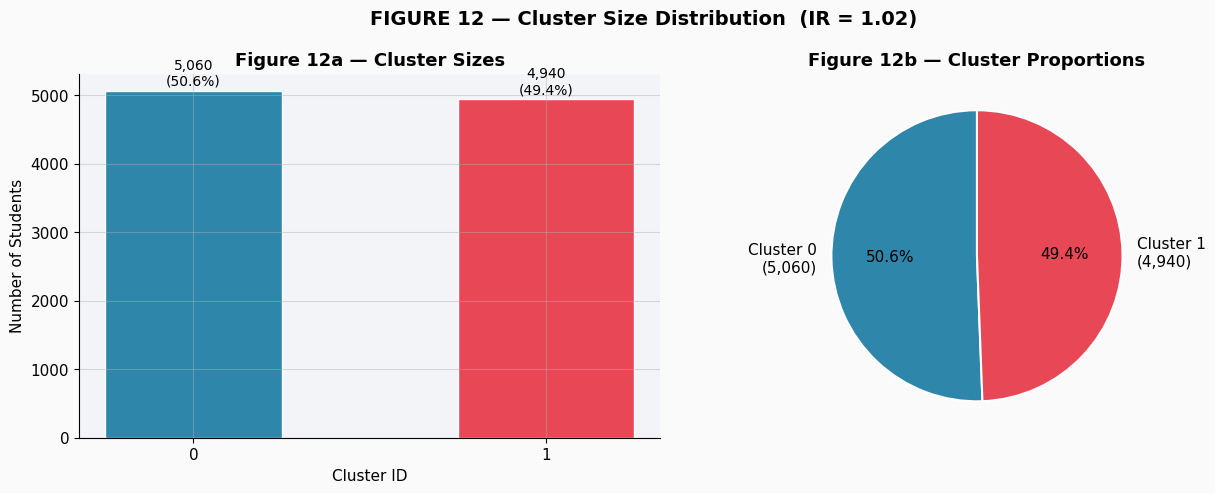

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(cluster_sizes.index, cluster_sizes.values,
              color=[PALETTE[k] for k in cluster_sizes.index],
              edgecolor='white', width=0.5)
for bar, (k, cnt) in zip(bars, cluster_sizes.items()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{cnt:,}\n({cnt/len(labels)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Number of Students')
ax.set_title('Figure 12a — Cluster Sizes')
ax.set_xticks(cluster_sizes.index)

ax = axes[1]
ax.pie(
    cluster_sizes.values,
    labels=[f'Cluster {k}\n({cnt:,})' for k, cnt in cluster_sizes.items()],
    autopct='%1.1f%%',
    colors=[PALETTE[k] for k in cluster_sizes.index],
    startangle=90,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'}
)
ax.set_title('Figure 12b — Cluster Proportions')

fig.suptitle(f'FIGURE 12 — Cluster Size Distribution  (IR = {cluster_ir:.2f})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_12_Cluster_Sizes.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Radar Chart: Feature Profiles — Figure 13

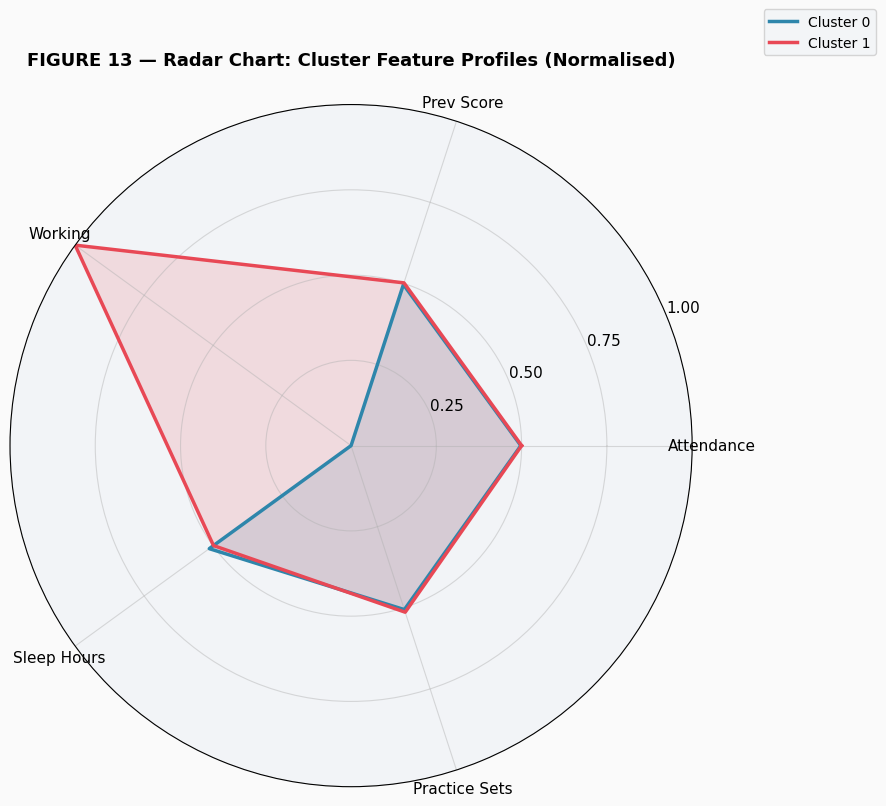

In [33]:
N_feat   = len(feature_names)
angles   = np.linspace(0, 2*np.pi, N_feat, endpoint=False).tolist() + [0]
f_labels = ['Attendance', 'Prev Score', 'Working', 'Sleep Hours', 'Practice Sets']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for k in range(OPTIMAL_K):
    vals = final_km.cluster_centers_[k].tolist() + [final_km.cluster_centers_[k][0]]
    ax.plot(angles, vals, color=PALETTE[k], lw=2.5, label=f'Cluster {k}')
    ax.fill(angles, vals, alpha=0.15, color=PALETTE[k])

ax.set_thetagrids(np.degrees(angles[:-1]), f_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title('FIGURE 13 — Radar Chart: Cluster Feature Profiles (Normalised)',
             fontsize=13, fontweight='bold', pad=28)
ax.legend(loc='upper right', bbox_to_anchor=(1.28, 1.15), fontsize=10)
plt.tight_layout()
plt.savefig('Figure_13_Radar_Chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Cluster Scatter Plots — Figure 14

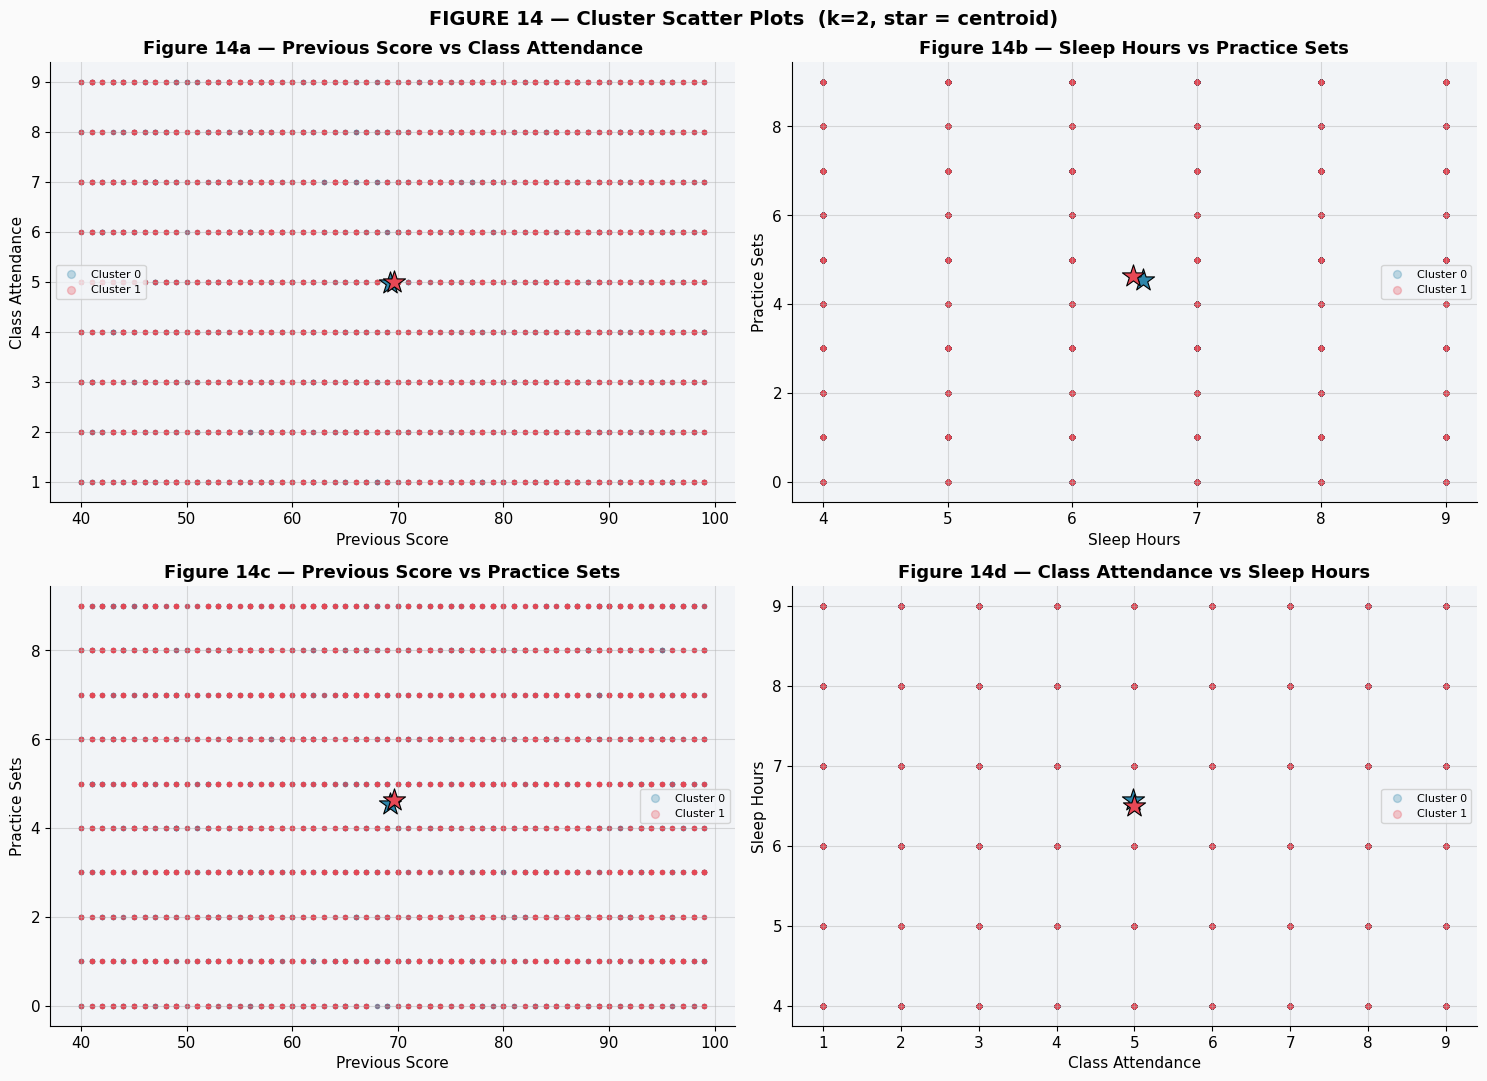

In [34]:
centroids_orig = final_km.cluster_centers_ * (col_max - col_min) + col_min
centroid_df    = pd.DataFrame(centroids_orig, columns=feature_names)

df_result = df.copy()
df_result['cluster'] = labels

pairs = [
    ('prev_score',    'attendance',    'Previous Score',   'Class Attendance'),
    ('sleep_hours',   'practice_sets', 'Sleep Hours',      'Practice Sets'),
    ('prev_score',    'practice_sets', 'Previous Score',   'Practice Sets'),
    ('attendance',    'sleep_hours',   'Class Attendance', 'Sleep Hours'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()
fig_idx = ['14a', '14b', '14c', '14d']

for ax, (xcol, ycol, xlabel, ylabel), fi in zip(axes, pairs, fig_idx):
    for k in range(OPTIMAL_K):
        mask = labels == k
        ax.scatter(df_result.loc[mask, xcol], df_result.loc[mask, ycol],
                   s=8, alpha=0.28, color=PALETTE[k], label=f'Cluster {k}')
        ax.scatter(centroid_df.loc[k, xcol], centroid_df.loc[k, ycol],
                   s=280, marker='*', color=PALETTE[k],
                   edgecolors='black', lw=0.8, zorder=6)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Figure {fi} — {xlabel} vs {ylabel}')
    ax.legend(fontsize=8, markerscale=2)

fig.suptitle(f'FIGURE 14 — Cluster Scatter Plots  (k={OPTIMAL_K}, star = centroid)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_14_Cluster_Scatter_Plots.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Mean Feature Values per Cluster — Figure 15

=== CLUSTER CENTROIDS (Original Scale) ===
         attendance  prev_score  working  sleep_hours  practice_sets
cluster                                                             
0             4.982      69.293      0.0        6.570          4.550
1             5.000      69.603      1.0        6.493          4.622


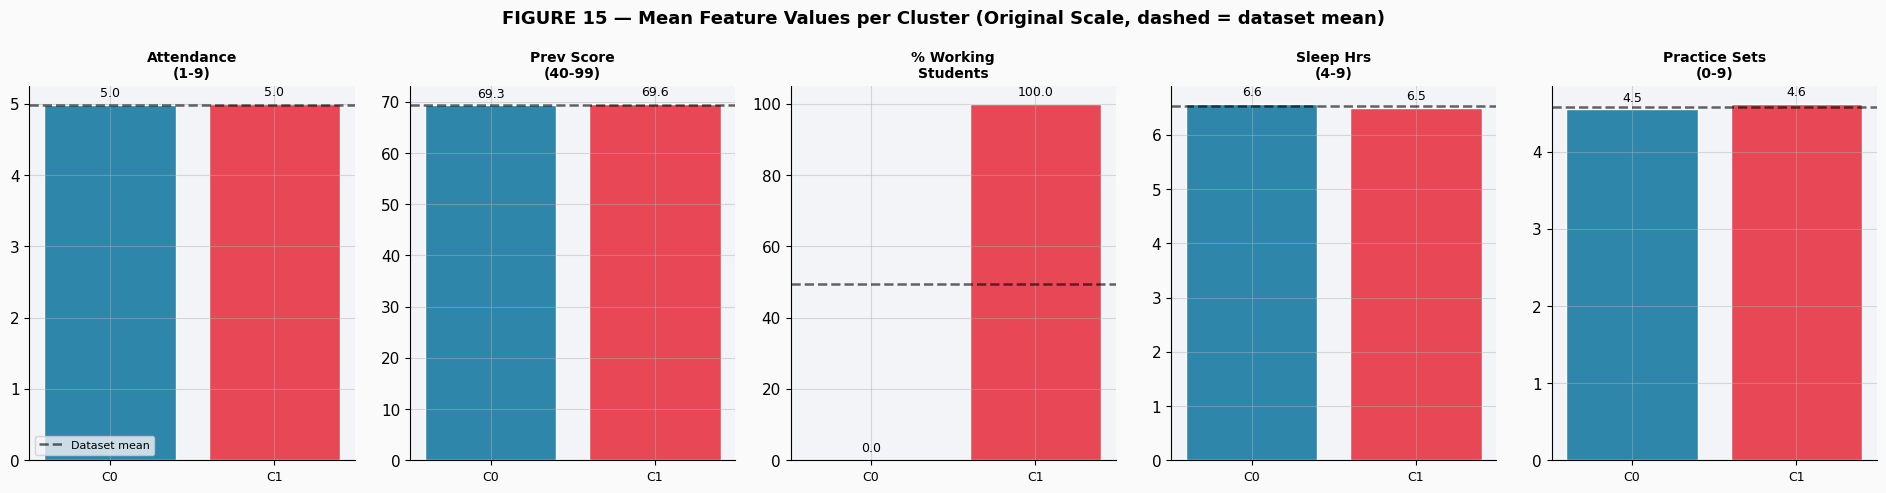

In [35]:
df_labeled    = pd.DataFrame(X_raw, columns=feature_names)
df_labeled['cluster'] = labels
cluster_means = df_labeled.groupby('cluster')[feature_names].mean()
grand_means   = df_labeled[feature_names].mean()

print('=== CLUSTER CENTROIDS (Original Scale) ===')
print(cluster_means.round(3).to_string())

f_display = ['Attendance\n(1-9)', 'Prev Score\n(40-99)',
             '% Working\nStudents', 'Sleep Hrs\n(4-9)', 'Practice Sets\n(0-9)']

fig, axes = plt.subplots(1, len(feature_names), figsize=(19, 5))
for ax, col, flbl in zip(axes, feature_names, f_display):
    vals = cluster_means[col].values
    if col == 'working':
        vals = vals * 100  # display as percentage
    gm   = grand_means[col] * (100 if col == 'working' else 1)

    bars = ax.bar(range(OPTIMAL_K), vals,
                  color=[PALETTE[k] for k in range(OPTIMAL_K)],
                  edgecolor='white')
    ax.axhline(gm, color='black', lw=1.8, linestyle='--', alpha=0.6, label='Dataset mean')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.015 * vals.max(),
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(flbl, fontsize=10)
    ax.set_xticks(range(OPTIMAL_K))
    ax.set_xticklabels([f'C{k}' for k in range(OPTIMAL_K)], fontsize=9)
    if ax == axes[0]: ax.legend(fontsize=8)

fig.suptitle('FIGURE 15 — Mean Feature Values per Cluster (Original Scale, dashed = dataset mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_15_Cluster_Mean_Features.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 Centroid Heatmap — Figure 16

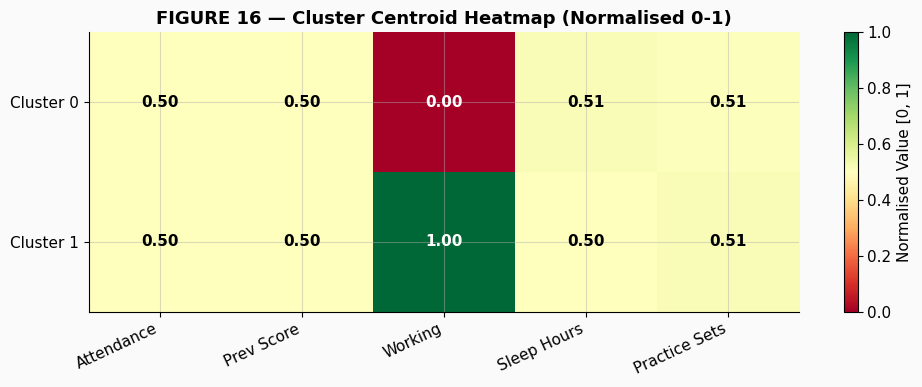

In [36]:
cent_norm = final_km.cluster_centers_

fig, ax = plt.subplots(figsize=(10, max(4, OPTIMAL_K)))
im = ax.imshow(cent_norm, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Normalised Value [0, 1]')

ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(['Attendance', 'Prev Score', 'Working', 'Sleep Hours', 'Practice Sets'],
                   rotation=25, ha='right', fontsize=11)
ax.set_yticks(range(OPTIMAL_K))
ax.set_yticklabels([f'Cluster {k}' for k in range(OPTIMAL_K)], fontsize=11)

for i in range(OPTIMAL_K):
    for j in range(len(feature_names)):
        v = cent_norm[i, j]
        tc = 'black' if 0.25 < v < 0.75 else 'white'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=11, color=tc, fontweight='bold')

ax.set_title('FIGURE 16 — Cluster Centroid Heatmap (Normalised 0-1)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_16_Centroid_Heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Silhouette Plot for Final Model — Figure 17

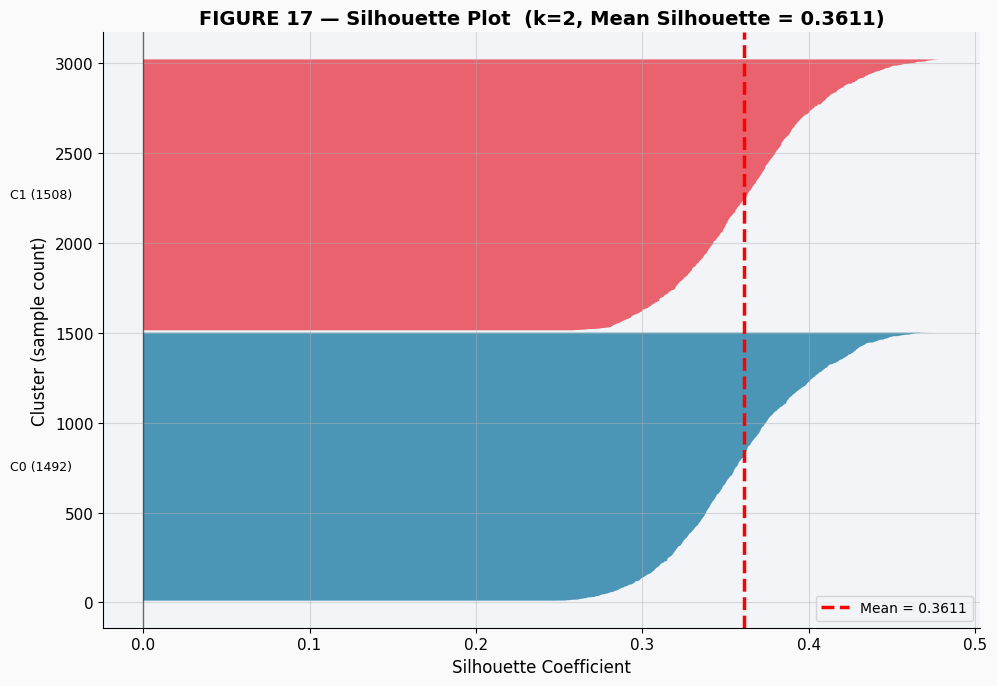

INSIGHT (Figure 17):
  Bars extending well to the right of the mean (red dashed) = well-formed clusters.
  Thin bars or bars left of 0 indicate weaker cluster membership.


In [37]:
fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
for k in range(OPTIMAL_K):
    ck_sil  = np.sort(sil_vals_final[sil_labs_final == k])
    size_k  = len(ck_sil)
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ck_sil,
                     facecolor=PALETTE[k], alpha=0.85)
    ax.text(-0.08, y_lower + size_k/2, f'C{k} ({size_k})', fontsize=9, va='center')
    y_lower = y_upper + 12

ax.axvline(final_sil, color='red', lw=2.5, linestyle='--',
           label=f'Mean = {final_sil:.4f}')
ax.axvline(0, color='black', lw=1.0, alpha=0.5)
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster (sample count)', fontsize=12)
ax.set_title(f'FIGURE 17 — Silhouette Plot  (k={OPTIMAL_K}, Mean Silhouette = {final_sil:.4f})',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Figure_17_Silhouette_Plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('INSIGHT (Figure 17):')
print('  Bars extending well to the right of the mean (red dashed) = well-formed clusters.')
print('  Thin bars or bars left of 0 indicate weaker cluster membership.')

---
## Phase 8 – Learner Archetypes and Academic Recommendations

In [38]:
working_pct_cluster = df_labeled.groupby('cluster')['working'].mean() * 100

archetype_map = {}

print('=' * 72)
print(f'  LEARNER ARCHETYPE PROFILES   k = {OPTIMAL_K}')
print('=' * 72)

for k in range(OPTIMAL_K):
    row  = cluster_means.loc[k]
    size = cluster_sizes[k]
    pct  = size / len(labels) * 100

    hi_score   = row['prev_score']    > grand_means['prev_score']
    hi_attend  = row['attendance']    > grand_means['attendance']
    hi_prac    = row['practice_sets'] > grand_means['practice_sets']
    hi_sleep   = row['sleep_hours']   > grand_means['sleep_hours']
    hi_working = working_pct_cluster[k] > 50

    if hi_score and hi_attend and hi_prac:
        archetype   = 'High Achiever — Engaged Learner'
        recommend   = 'Enriched coursework, research roles, peer mentoring positions.'
    elif hi_score and not hi_attend and not hi_prac:
        archetype   = 'Self-Directed High Performer'
        recommend   = 'Online resources, project-based assessments, case studies.'
    elif not hi_score and hi_working and not hi_attend:
        archetype   = 'Struggling Working Professional'
        recommend   = 'Flexible schedules, recorded lectures, weekend sessions.'
    elif not hi_score and hi_attend and not hi_prac:
        archetype   = 'Consistent Attendee — Under-Performer'
        recommend   = 'One-on-one tutoring, small study groups, foundational support.'
    elif hi_sleep and not hi_prac and not hi_attend:
        archetype   = 'Passive Learner — Minimal Engagement'
        recommend   = 'Gamified practice sets, accountability check-ins, structured plans.'
    else:
        archetype   = 'Average Learner — Moderate Engagement'
        recommend   = 'Targeted workshops, mixed study groups, balanced course load.'

    archetype_map[k] = archetype

    print(f'\n  Cluster {k}  [{size:,} students  {pct:.1f}%]')
    print(f'  Archetype     : {archetype}')
    print(f'  Prev Score    : {row["prev_score"]:.1f}  ({'above' if hi_score   else 'below'} avg {grand_means["prev_score"]:.1f})')
    print(f'  Attendance    : {row["attendance"]:.1f}  ({'above' if hi_attend  else 'below'} avg {grand_means["attendance"]:.1f})')
    print(f'  Practice Sets : {row["practice_sets"]:.1f}  ({'above' if hi_prac    else 'below'} avg {grand_means["practice_sets"]:.1f})')
    print(f'  Sleep Hours   : {row["sleep_hours"]:.1f}  ({'above' if hi_sleep   else 'below'} avg {grand_means["sleep_hours"]:.1f})')
    print(f'  Working (%)   : {working_pct_cluster[k]:.1f}%')
    print(f'  Recommendation: {recommend}')

print('\n' + '=' * 72)

  LEARNER ARCHETYPE PROFILES   k = 2

  Cluster 0  [5,060 students  50.6%]
  Archetype     : Passive Learner — Minimal Engagement
  Prev Score    : 69.3  (below avg 69.4)
  Attendance    : 5.0  (below avg 5.0)
  Practice Sets : 4.5  (below avg 4.6)
  Sleep Hours   : 6.6  (above avg 6.5)
  Working (%)   : 0.0%
  Recommendation: Gamified practice sets, accountability check-ins, structured plans.

  Cluster 1  [4,940 students  49.4%]
  Archetype     : High Achiever — Engaged Learner
  Prev Score    : 69.6  (above avg 69.4)
  Attendance    : 5.0  (above avg 5.0)
  Practice Sets : 4.6  (above avg 4.6)
  Sleep Hours   : 6.5  (below avg 6.5)
  Working (%)   : 100.0%
  Recommendation: Enriched coursework, research roles, peer mentoring positions.



---
## Phase 9 – Export Results

In [39]:
df_result['archetype'] = df_result['cluster'].map(archetype_map)
df_result.to_csv('student_cluster_assignments.csv', index=False)

centroid_df['archetype'] = centroid_df.index.map(archetype_map)
centroid_df.round(3).to_csv('cluster_centroids.csv')

print('=== EXPORTS COMPLETE ===')
print('  student_cluster_assignments.csv  — all students with cluster ID and archetype label')
print('  cluster_centroids.csv            — centroid profiles per cluster (original scale)')
print('  Figure_01 to Figure_17.png       — all labelled figures for reflection screenshots')
print()
print('=== FINAL PIPELINE SUMMARY ===')
print(f'  Students processed      : {len(df_result):,}')
print(f'  Optimal k               : {OPTIMAL_K}')
print(f'  WCSS (Inertia)          : {final_km.inertia_:.4f}')
print(f'  Silhouette Score        : {final_sil:.4f}  (higher is better)')
print(f'  Davies-Bouldin Index    : {final_dbi:.4f}  (lower is better)')
print(f'  Cluster Imbalance Ratio : {cluster_ir:.3f}')
print(f'  Figures generated       : 17')

=== EXPORTS COMPLETE ===
  student_cluster_assignments.csv  — all students with cluster ID and archetype label
  cluster_centroids.csv            — centroid profiles per cluster (original scale)
  Figure_01 to Figure_17.png       — all labelled figures for reflection screenshots

=== FINAL PIPELINE SUMMARY ===
  Students processed      : 10,000
  Optimal k               : 2
  WCSS (Inertia)          : 4066.5192
  Silhouette Score        : 0.3611  (higher is better)
  Davies-Bouldin Index    : 1.2396  (lower is better)
  Cluster Imbalance Ratio : 1.024
  Figures generated       : 17
